<a href="https://colab.research.google.com/github/leoruggiero/Sprint-8-Python-Leonardo-Ruggiero/blob/main/Sprint8_Python_LeonardoRuggiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarea S8.01. Analítica de datos en Pandas


# Nivel 1 - EDA estructurado y limpieza básica

## Ejercicio 1: Exploración inicial del dataset
---

🎯 Objetivo: entender la estructura general del dataset y detectar posibles problemas antes de empezar a limpiar o transformar datos.
En este ejercicio debes realizar una exploración inicial del DataFrame para responder, como mínimo, a las siguientes preguntas:



**Primero hago la importacion de datos.**

In [68]:
# importacion de datos

from google.colab import files
uploaded = files.upload()

Saving sprint8_complex.xlsx to sprint8_complex.xlsx


**Cuántas filas y columnas tiene el dataset?**

---

RESPUESTA: Utilizando el atributo '.shape' sobre el DataFrame, obtuve una tupla que me indica exactamente 1010 filas y 20 columnas.

In [69]:
import pandas as pd
import io

nome_del_arquivo = 'sprint8_complex.xlsx'

df = pd.read_excel(io.BytesIO(uploaded[nome_del_arquivo]))

print(df.shape)

(1010, 20)


**Qué tipo de datos contiene cada columna?**

---

Al ejecutar el método `.info()`, he comprobado que las 20 columnas están catalogadas con el tipo de dato `object`. Esto ocurre porque Pandas está interpretando todo como texto, lo cual me alerta de un problema evidente, ya que tenemos variables que claramente deberían ser numéricas (como el salario o los años) o booleanas.

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Dades de l'enquesta de treballadors 2025  1008 non-null   object
 1   Unnamed: 1                                1007 non-null   object
 2   Unnamed: 2                                1007 non-null   object
 3   Unnamed: 3                                1007 non-null   object
 4   Unnamed: 4                                1007 non-null   object
 5   Unnamed: 5                                1007 non-null   object
 6   Unnamed: 6                                1007 non-null   object
 7   Unnamed: 7                                1007 non-null   object
 8   Unnamed: 8                                1007 non-null   object
 9   Unnamed: 9                                967 non-null    object
 10  Unnamed: 10                               1007 n

**Hay filas duplicadas?**

---

Apliqué el método `.duplicated()` para identificar registros repetidos en todo el DataFrame y lo encadené con `.sum()` para obtener el recuento total. El resultado arrojado fue 0, por lo que concluyo que no hay filas completamente idénticas en esta primera carga.

In [71]:
# » ¿Hay filas duplicadas?
total_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {total_duplicados}")
if total_duplicados > 0:
    print("\nMuestra de filas duplicadas:")
    display(df[df.duplicated()].head())

Filas duplicadas: 0


**Los datos parecen coherentes a primera vista?**

---

Al imprimir la muestra con `df.describe(include='all')`, observé directamente que las filas de índice 0 y 1 contienen metadatos sueltos ("Generades aleatòriament per seguretat") y valores `NaN`. Los nombres reales de las variables están en la fila 2. Esto explica exactamente por qué `.sample()` nos devolvió columnas nombradas genéricamente como `Unnamed: 1`.

In [72]:
df.describe(include='all')



,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
count,1008,1007,1007,1007,1007,1007,1007,1007,1007,967,1007,420,586,1006,1006,710,659,316,262,937
unique,1008,104,469,992,7,46,36,16,52,10,856,2,3,6,15,9,3,171,85,187
top,990,AdriÃ,Ferrer,90585882A,Espanya,Palma,10.0,9.0,1982.0,D,n/d,True,True,Grup A,Data Analyst,0.0,False,80000,25.0,-5.0
freq,1,34,22,6,719,58,38,90,32,325,14,419,584,466,142,292,330,74,61,21


 » Detectas posibles problemas o inconsistencias evidentes?

 ---

Problemas graves con el nombre de las columnas, de formato en datos numéricos en salarios, falta de un padron en Género : (`'Dona', 'H', 'D', 'F', 'Home', 'NC', 'M', nan, 'A', '??'`), problemas de Encoding (Caracteres extraños `'CÃrrec'`
) y redundancia estructural en el diseño del dataset (`'Fills'`, `'No Fills'` y `'Nombre_fills'`)

In [73]:

print(df['Unnamed: 10'].unique()[:10])
print(df.isna().sum())
print(df['Unnamed: 9'].unique()[:10])
print(df['Unnamed: 11'].unique()[:10])

[nan 'Salari mensual' '1,469 â‚¬' '2,718 â‚¬' '1358 euros' '1,478 â‚¬'
 '1,284 â‚¬' '2,069 â‚¬' '2,349 â‚¬' '2,855 â‚¬']
Dades de l'enquesta de treballadors 2025      2
Unnamed: 1                                    3
Unnamed: 2                                    3
Unnamed: 3                                    3
Unnamed: 4                                    3
Unnamed: 5                                    3
Unnamed: 6                                    3
Unnamed: 7                                    3
Unnamed: 8                                    3
Unnamed: 9                                   43
Unnamed: 10                                   3
Unnamed: 11                                 590
Unnamed: 12                                 424
Unnamed: 13                                   4
Unnamed: 14                                   4
Unnamed: 15                                 300
Unnamed: 16                                 351
Unnamed: 17                                 694
Unnamed: 18    

## Ejercicio 2: Validaciones básicas de los datos y decisiones de eliminación

---

En este ejercicio tendrás que validar aspectos clave del dataset que son críticos en cualquier contexto real de análisis de datos, tomando decisiones justificadas sobre la validez o eliminación de registros .


» Corregir posibles problemas de codificación y acentuación en los nombres de las columnas y en los valores de texto, si procede.
» Detectar y eliminar filas duplicadas exactas, indicando cuántos registros se han eliminado.

» Comprobar la unicidad del DNI. En caso de detectar DNIs duplicados, deberás analizar la coherencia de la información asociada y descartar o anular los registros que no sean fiables, justificando claramente la decisión tomada.

» Identificar los campos clave que no deberían contener valores nulos, detectar registros con información insuficiente y eliminar únicamente aquellas filas completamente vacías o con información irrecuperable o no sustituible, explicando por qué no es posible ni razonable imputarlas.


**Cargo y limpieza**

---

Antes de empezar el ejercicio, tuve que cargas los datos hacendo la limpieza de la primera columna que es un indice oculto de pandas `if datos_trabajadores.columns[0].startswith('Unnamed')`. Luego reconstruyo el dataset eliminando esa primera columna `iloc[:, 1:]`. Hice un print para comprobar el numero de filas e .head para saber se todo fue cargado correctamente.

In [74]:
import io

datos_trabajadores = pd.read_excel(io.BytesIO(uploaded[nome_del_arquivo]), sheet_name=0, skiprows=3)

if datos_trabajadores.columns[0].startswith('Unnamed'):
    datos_trabajadores = datos_trabajadores.iloc[:, 1:]

print(f"Dimensiones iniciales del dataset: {datos_trabajadores.shape[0]} filas y {datos_trabajadores.shape[1]} columnas.")
datos_trabajadores.head(2)

Dimensiones iniciales del dataset: 1007 filas y 19 columnas.


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7


» **Existen identificadores únicos (DNI) para cada persona?**

---

Si pero hay DNI duplicados.
Decidí utilizar el método `duplicated(subset=['DNI'], keep=False)`. El parámetro que me permite capturar todas las apariciones de un DNI repetido, no solo la segunda o tercera vez que aparece.
Opté por extraer los índices de estos conflictos (`dnis_duplicados.index`) y eliminarlos usando el método `.drop()`. Quite estos registros antes que introducir datos falsos en el análisis posterior. He implementado variables de control (`num_dnis_conflictivos` y `len(indices_a_eliminar)`) para documentar e imprimir por pantalla exactamente el volumen de datos descartados por falta de fiabilidad.

In [75]:
dnis_duplicados = datos_trabajadores[datos_trabajadores.duplicated(subset=['DNI'], keep=False)]
num_dnis_conflictivos = dnis_duplicados['DNI'].nunique()

print(f"Número de DNIs con registros duplicados o conflictivos: {num_dnis_conflictivos}")

filas_antes_dni = datos_trabajadores.shape[0]
indices_a_eliminar = dnis_duplicados.index
datos_trabajadores.drop(index=indices_a_eliminar, inplace=True)

print(f"Se eliminaron {len(indices_a_eliminar)} filas duplicadas no fiables en el DNI.")
print(f"Filas restantes: {datos_trabajadores.shape[0]}")

Número de DNIs con registros duplicados o conflictivos: 9
Se eliminaron 24 filas duplicadas no fiables en el DNI.
Filas restantes: 983


» **Qué vas a hacer con las filas duplicadas o registros repetidos?**

---

Elimine las filas duplicadas \de todo el dataset para aprovechando la ola de limpeza del ejercicio.

In [76]:
duplicados_exactos = datos_trabajadores.duplicated().sum()
print(f"Filas duplicadas exactas encontradas: {duplicados_exactos}")

datos_trabajadores.drop_duplicates(keep='first', inplace=True)
print(f"Eliminación completada. Filas restantes: {datos_trabajadores.shape[0]}")

Filas duplicadas exactas encontradas: 0
Eliminación completada. Filas restantes: 983


» **Existen valores obligatorios que faltan o información incoherente?**

---

Si. Exitem filas vacias, registros sin identificador clave (DNI) y un pais llamado Narnia. Todo fue limpio usando los drops abajo. Aproveche para corigir tambien el valor decimal de los numeros de fecha de nascimiento y sueldo.

In [77]:
filas_vacias = datos_trabajadores.dropna(how='all').shape[0]
datos_trabajadores.dropna(how='all', inplace=True)

dnis_nulos = datos_trabajadores['DNI'].isna().sum()
datos_trabajadores.dropna(subset=['DNI'], inplace=True)
print(f"Filas eliminadas por ausencia de DNI (irrecuperables): {dnis_nulos}")

columnas_fechas = ['Dia de Naixement', 'Mes de Naixement', 'Any de Naixement']
for col in columnas_fechas:
    if col in datos_trabajadores.columns:
        datos_trabajadores[col] = datos_trabajadores[col].astype('Int64')

datos_trabajadores.to_csv("sprint10_limpio_ejercicio2.csv", index=False)
print(f"\n Dimensión final: {datos_trabajadores.shape[0]} filas.")
datos_trabajadores[columnas_fechas].head()

Filas eliminadas por ausencia de DNI (irrecuperables): 0

 Dimensión final: 982 filas.


,Dia de Naixement,Mes de Naixement,Any de Naixement
0,23,3,1958
1,8,11,1960
2,27,4,1961
3,13,10,1985
4,29,11,1965


**Se detectaron formatos incorrectos, errores de codificación o valores imposibles?**

---
Sí. Tal y como se observó en el ejercicio 1, el dataset presenta múltiples defectos de formato. En primer lugar, elaboré un diccionario para la sustitución de caracteres, realicé la corrección de los nombres de las columnas e hice una limpieza de los símbolos en Salari_mensual (es decir, todos los valores fueron limpios para el proximo ejercicio).

In [78]:
def limpiar_caracteres(texto):
    if not isinstance(texto, str):
        return texto

    # Dicionário de substituição baseado no que vimos no seu arquivo
    # Adicione aqui qualquer outro erro estranho que aparecer
    mapa_erro = {
        'Ã§': 'ç', 'Ã³': 'ó', 'Ã©': 'é', 'Ã¡': 'á',
        'Ã ': 'à', 'Ã±': 'ñ', 'Ã¨': 'è', 'Ã ': 'à',
        'CÃ rrec': 'Càrrec', 'GÃ¨nere': 'Gènere',
        'â‚¬': '€', 'Ã´': 'ô', 'Ã­': 'í'
    }

    for erro, acerto in mapa_erro.items():
        texto = texto.replace(erro, acerto)
    return texto

# 1. Corrigir nomes das colunas
# Substituímos os nomes corrompidos manualmente caso necessário
datos_trabajadores.columns = datos_trabajadores.columns.str.replace('CÃ rrec', 'Càrrec', regex=False)
datos_trabajadores.columns = datos_trabajadores.columns.str.replace('GÃ¨nere', 'Gènere', regex=False)

# 2. Aplicar a limpeza nas colunas de texto
columnas_texto = ['Nom', 'Cognoms', 'País d\'origen', 'Ciutat', 'Grup Professional', 'Càrrec']
for col in columnas_texto:
    if col in datos_trabajadores.columns:
        datos_trabajadores[col] = datos_trabajadores[col].apply(limpiar_caracteres)

# 3. Limpeza adicional para valores como "1,644 â‚¬" ou "1358 euros"
def limpiar_salario(valor):
    if isinstance(valor, str):
        valor = valor.replace('â‚¬', '').replace('euros', '').replace(',', '').strip()
        return float(valor) if valor.replace('.', '').isdigit() else None
    return valor

if 'Salari mensual' in datos_trabajadores.columns:
    datos_trabajadores['Salari mensual'] = datos_trabajadores['Salari mensual'].apply(limpiar_salario)

datos_trabajadores.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23,3,1958,Dona,1469.0,True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8,11,1960,H,2718.0,NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27,4,1961,D,1358.0,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13,10,1985,H,1478.0,True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29,11,1965,Dona,1284.0,NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1,8,1978,D,2069.0,NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,25,9,1971,D,2349.0,NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,8,9,1962,H,2855.0,True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
8,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,8,3,1963,D,1338.0,NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32,0,1940,H,1450.0,True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1


## Ejercicio 3: Transformaciones necesarias y preparación del dataset

---

🎯 Objetivo: preparar el dataset para que sea coherente, analizable y estructuralmente correcto antes de realizar cualquier análisis descriptivo.

En este ejercicio deberás aplicar transformaciones básicas pero esenciales, orientadas a mejorar la calidad de los datos y facilitar el posterior análisis.

Aspectos a revisar y transformar:

» ¿Los valores categóricos están normalizados y son consistentes?

» ¿ Los valores nulos son coherentes con la información disponible?

» ¿Existe redundancia de variables que pueda generar problemas
analíticos?

» ¿ Las variables contextuales (como temperatura, salario) están completas y preparadas para el análisis?
Concretamente, tendrás que:

» Normalizar los valores categóricos para evitar ambigüedades (por ejemplo, valores que representan el mismo concepto pero están escritos de forma diferente).

» Revisar la coherencia de los valores nulos, asegurando que:
Las personas con kilometraje anual y consumo medio asociados disponen de coche. En los casos en que conste consumo medio pero no kilometraje anual, será necesario decidir cómo resolver esta incoherencia de forma justificada.
Las personas que tienen un valor en el número de hijos tienen efectivamente hijos.

» Unificar la información sobre hijos en una única columna, ya que mantener varias columnas con información complementaria no es óptimo y puede generar problemas analíticos (redundancia o multicolinealidad).

» Validar la temperatura media. En caso de que esa información falte, deberás imputarla utilizando un criterio razonable (por ciudad o por un nivel superior justificado).

» Revisar e imputar los salarios faltantes, aplicando criterios analíticos coherentes (como cargo, grupo profesional, ciudad, género o franja de edad).

» **Los valores nulos son coherentes con la información disponible?**

---

Sí, la gran mayoría de los valores nulos detectados **son totalmente coherentes**, ya que responden a un problema de diseño en la recolección de datos y no a una pérdida de información.



In [79]:
datos_trabajadores.isnull().sum()

,0
Nom,0
Cognoms,0
DNI,0
País d'origen,0
Ciutat,0
Dia de Naixement,0
Mes de Naixement,0
Any de Naixement,0
Gènere,39
Salari mensual,37



Tras confirmar que los nulos en el bloque de descendencia eran estructurales, diseñé un bloque de código para consolidar la información en una sola variable (`Nombre_fills`) y eliminar la redundancia. Utilicé `.loc[]` para cruzar la información: si un registro indicaba que no tenía hijos (`No Fills == True` o `Fills == False`), forcé el valor de `Nombre_fills` a 0. Envolví estas sentencias en condicionales `if` para comprobar la existencia previa de la columna, evitando que el notebook arroje errores si la celda se ejecuta accidentalmente más de una vez.
En el dataset original, el número de hijos estaba en formato flotante (ej. 3.0), lo cual es analíticamente incorrecto para una variable discreta. Aproveché para rellenar los nulos residuales con 0 y encadené el método `.astype(int)` para transformar la columna a números enteros. Finalmente, utilicé el método `.drop()` para eliminar las columnas categóricas redundantes. Añadir el parámetro `errors='ignore'` es una buena práctica que garantiza que el código siga siendo ejecutable sin romper el flujo del pipeline si las columnas ya han sido eliminadas previamente.

In [80]:
# 1. Imputación lógica solo si las columnas redundantes aún existen en el dataset
if 'No Fills' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['No Fills'] == True, 'Nombre_fills'] = 0
if 'Fills' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['Fills'] == False, 'Nombre_fills'] = 0

# 2. Asegurar que 'Nombre_fills' sea entero y no tenga nulos
if 'Nombre_fills' in datos_trabajadores.columns:
    datos_trabajadores['Nombre_fills'] = datos_trabajadores['Nombre_fills'].fillna(0).astype(int)

# 3. Eliminar variables redundantes de forma segura (si ya no están, no hace nada)
datos_trabajadores.drop(columns=['Fills', 'No Fills'], errors='ignore', inplace=True)

print("Redundancia de hijos controlada sin errores.")


Redundancia de hijos controlada sin errores.


» **Los valores categóricos están normalizados y son consistentes?**

---

No, detecté una gran falta de consistencia en la variable `Género`. En lugar de tener categorías limpias, existía valores caóticos para el mismo concepto (ej:`'Dona', 'D' y 'F' para mujeres`), además de valores nulos o incomprensibles. Para poder segmentar o analizar a los trabajadores por género, era obligatorio normalizar esta columna.

1. **Mapeo eficiente con diccionarios:** Construí el diccionario `mapeo_genero` que asocia cada valor detectado con su categoría final estandarizada ('Mujer', 'Hombre', 'Otros/No Consta').
2. **Búsqueda flexible:** Como detectamos previamente problemas de encoding en el dataset, diseñe una busqueda dinámica con un bucle `for` para identificar la columna original sin importar como estuviera acentuada o escrita ('gènere', 'gnere', etc.).
3. **Transformación de nulos:** Utilicé el método `.map()` de Pandas, para transformar categorías basadas en diccionarios. Inmediatamente después, encadené un `.fillna('Otros/No Consta')` para capturar cualquier valor nulo original o texto que no estuviera en mi diccionario.
4. **Limpieza estructural:** Finalmente, creé una nueva columna oficial llamada `Gènere_Limpio` y apliqué un `.drop()` defensivo (`errors='ignore'`) sobre la columna vieja para no arrastrar datos en el DataFrame.


In [81]:
mapeo_genero = {
    'Dona': 'Mujer', 'D': 'Mujer', 'F': 'Mujer',
    'Home': 'Hombre', 'H': 'Hombre', 'A': 'Otros/No Consta'
}

columna_genero_origen = None
for col in datos_trabajadores.columns:
    if col.lower() in ['gnere', 'gènere', 'génere', 'gènere_limpio']:
        columna_genero_origen = col
        break

if columna_genero_origen:
    datos_trabajadores['Gènere_Limpio'] = datos_trabajadores[columna_genero_origen].map(mapeo_genero).fillna('Otros/No Consta')

    if columna_genero_origen != 'Gènere_Limpio':
        datos_trabajadores.drop(columns=[columna_genero_origen], errors='ignore', inplace=True)

print("Columna 'Gènere_Limpio' procesada correctamente:")
print(datos_trabajadores['Gènere_Limpio'].value_counts())

Columna 'Gènere_Limpio' procesada correctamente:
Gènere_Limpio
Mujer              538
Hombre             323
Otros/No Consta    121
Name: count, dtype: int64


» **Existe redundancia de variables que pueda generar problemas
analíticos?**

---

Si que existia pero como demostré en el ejercicio anterior, la variable de salario si está casi preparada. Ya fue normalizada de texto a numérico, limpia para poder recibir la sigla de euros en esta etapa final de correcion. Use una funcion condicional para arreglar tal valores.

In [82]:
import numpy as np
import pandas as pd

def limpiar_salario(valor):
    if pd.isna(valor):
        return np.nan
    valor_str = str(valor).lower().strip()
    if 'tres mil' in valor_str:
        return 3000.0
    if 'mil vuit-cents' in valor_str:
        return 1800.0
    valor_str = valor_str.replace('â‚¬', '').replace('€', '').replace('euros', '').strip()
    valor_str = valor_str.replace(',', '')
    try:
        return float(valor_str)
    except:
        return np.nan

# 1. Transformar el texto sucio a número puro
if 'Salari mensual' in datos_trabajadores.columns:
    if not pd.api.types.is_numeric_dtype(datos_trabajadores['Salari mensual']):
        datos_trabajadores['Salari mensual'] = datos_trabajadores['Salari mensual'].apply(limpiar_salario)

datos_trabajadores['Salari mensual'] = datos_trabajadores.groupby('Grup Professional')['Salari mensual'].transform(lambda x: x.fillna(x.mean()))

datos_trabajadores['Salari_mensual_Euros'] = datos_trabajadores['Salari mensual'].apply(lambda x: f"{int(x)} €" if pd.notna(x) else "0 €")

print("Variable 'Salari mensual' numérica calculada.")
print("Nueva columna 'Salari_mensual_Euros' generada con formato homogéneo:")
print(datos_trabajadores[['Salari mensual', 'Salari_mensual_Euros']].head(5))

Variable 'Salari mensual' numérica calculada.
Nueva columna 'Salari_mensual_Euros' generada con formato homogéneo:
   Salari mensual Salari_mensual_Euros
0          1469.0               1469 €
1          2718.0               2718 €
2          1358.0               1358 €
3          1478.0               1478 €
4          1284.0               1284 €


» **Las variables contextuales (como temperatura, salario) están completas y preparadas para el análisis?**

El bloque de movilidad y entorno (`Te_cotxe`, `Km_anuals`, `Consum_mitja_L_100km`, `Temperatura_mitjana_ciutat`): Despues de analizar concluí que estas variables aún no están preparadas. Presentan nulos e inconsistencias lógicas que deben ser tratadas:

Es lógicamente imposible que un empleado que no tiene coche (`Te_cotxe == False` o nulo) registre kilómetros anuales o consumo de combustible.

Faltan datos climáticos en algunos registros. Rellenarlos con una media global sería un error analítico grave, ya que el clima varía drásticamente según la geografía.

Para preparar estas variables, aplicaré una limpieza basada en reglas de negocio. Primero, forzaré a `0` (o `NaN` según corresponda) los kilómetros y el consumo de aquellos empleados que no poseen vehículo. Segundo, para la temperatura, aplicaré la misma lógica avanzada que usé con el salario: imputaré los valores nulos calculando la media térmica agrupada por la `Ciutat` de cada empleado.

In [83]:
if 'Te_cotxe' in datos_trabajadores.columns:
    datos_trabajadores['Te_cotxe'] = datos_trabajadores['Te_cotxe'].fillna(False).astype(bool)

if 'Km_anuals' in datos_trabajadores.columns and 'Consum_mitja_L_100km' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['Te_cotxe'] == False, ['Km_anuals', 'Consum_mitja_L_100km']] = 0

if 'Temperatura_mitjana_ciutat' in datos_trabajadores.columns and 'Ciutat' in datos_trabajadores.columns:
    datos_trabajadores['Temperatura_mitjana_ciutat'] = datos_trabajadores.groupby('Ciutat')['Temperatura_mitjana_ciutat'].transform(lambda x: x.fillna(x.mean()))

datos_trabajadores['Temperatura_mitjana_ciutat'] = datos_trabajadores['Temperatura_mitjana_ciutat'].fillna(datos_trabajadores['Temperatura_mitjana_ciutat'].mean())

print("Variables contextuales (Movilidad y Temperatura) procesadas y listas para análisis.")

Variables contextuales (Movilidad y Temperatura) procesadas y listas para análisis.


/tmp/ipykernel_6026/1186234212.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_trabajadores['Te_cotxe'] = datos_trabajadores['Te_cotxe'].fillna(False).astype(bool)


##  Ejercicio 4: Primeros análisis descriptivos

🎯 Objetivo: obtener una primera visión global del dataset una vez aplicadas las transformaciones básicas, mediante estadísticas descriptivas y comparaciones simples entre grupos relevantes.
Aspectos a revisar y analizar:

» Construir tablas resumen descriptivas.

» Realizar comparaciones básicas entre grupos relevantes.
Concretamente, tendrás que:

» Construir tablas resumen descriptivas de salarios como una tabla resumen que permita ver el sueldo medio, medio, mínimo y máximo por Género. Ordena la tabla en función del sueldo medio.

» Crear una tabla resumen con el salario medio por género (filas) y país de origen (columnas). Añade las medias a los márgenes de la mesa. Aplica formato condicional a la mesa para ver en un color más intenso los valores más elevados.

In [84]:
# 1. Identificar la columna de género según cómo haya quedado guardada en tu dataset
columna_genero_ok = 'Gènere_Limpio' if 'Gènere_Limpio' in datos_trabajadores.columns else 'Género'

# 2. Construir la tabla resumen descriptiva
tabla_descriptiva_genero = datos_trabajadores.groupby(columna_genero_ok)['Salari mensual'].agg(
    Sueldo_Medio='mean',
    Sueldo_Mediano='median',
    Sueldo_Mínimo='min',
    Sueldo_Máximo='max'
)

# 3. Ordenar por sueldo medio de forma descendente
tabla_descriptiva_genero = tabla_descriptiva_genero.sort_values(by='Sueldo_Medio', ascending=False)

print("Estadísticas descriptivas del salario mensual por Género")
tabla_descriptiva_genero.style.format("{:.2f} €")

Estadísticas descriptivas del salario mensual por Género


,Sueldo_Medio,Sueldo_Mediano,Sueldo_Mínimo,Sueldo_Máximo
Gènere_Limpio,,,,
Otros/No Consta,1573.05 €,1377.00 €,1.10 €,3610.00 €
Hombre,1545.22 €,1412.00 €,1.01 €,3672.00 €
Mujer,1359.59 €,1282.00 €,1.01 €,3564.00 €


In [85]:
tabla_cruze_salarios = pd.pivot_table(
    datos_trabajadores,
    values='Salari mensual',
    index='Gènere_Limpio',
    columns='Pas d\'origen',
    aggfunc='mean',
    margins=True,
    margins_name='Media Global'
)

print("Salario medio cruzado por Género y País de origen (Análisis Descriptivo)")
tabla_cruze_salarios.style.format("{:.2f} €").background_gradient(cmap='YlOrRd', axis=None)

KeyError: "Pas d'origen"

# Nivel 2 - Análisis con datos enriquecidos y estructuras múltiples





## Ejercicio 1: Enriquecimiento mediante datasets externos

🎯 Objetivo: ampliar el dataset principal integrando información contextual externa y evaluar el impacto analítico de las decisiones de fusión.
Aspectos a revisar y analizar

» ¿ Las diferentes fuentes de datos son coherentes y compatibles entre sí para poder calcular un salario ajustado?

» ¿ La información contextual incorporada (coste de vida, políticas salariales) es suficiente para aplicar incrementos de forma consistente?

» ¿Existen vacíos de información que impidan calcular correctamente el incremento salarial en algunos registros?

» ¿Es necesario tomar decisiones analíticas cuando la información contextual es parcial o ausente?

» ¿Cómo pueden estas decisiones influir en el cálculo del salario ajustado y su posterior interpretación?
Concretamente, tendrás que:

» Integrar el dataset principal con:
El dataset contextual de ciudades.
La política salarial definida en formato JSON

» Calcular un incremento salarial total combinando:
Grupo profesional.
Situación familiar.
Franja de edad.
Coste de vida de la ciudad.

» Identificar qué registros no pueden recibir alguno de los ajustes y explicar su motivo.

» Decidir, de modo razonado, cómo tratar estos casos en el cálculo del salario ajustado, justificando el impacto analítico de la decisión tomada.


In [ ]:
# importacion de datos

from google.colab import files
uploaded = files.upload()

Saving ciutats_context.csv to ciutats_context.csv
Saving politica_salarial.json to politica_salarial.json


In [ ]:
import pandas as pd
import json

# cargando el archivo
df_cidades = pd.read_csv('ciutats_context.csv', encoding='latin1')

with open('politica_salarial.json', 'r', encoding='utf-8-sig') as f:
    politica = json.load(f)

# 2. Definição da função para categorizar o custo de vida
def classificar_custo(index):
    if index < 70: return 'low'
    elif index <= 80: return 'medium'
    else: return 'high'

# Hice una columna auxiliar no CSV para el merge
df_cidades['custo_categoria'] = df_cidades['Cost_vida_index'].apply(classificar_custo)

# 3. Ejemplo del cálculo del incremento (Lógica aplicada)
def calcular_incremento(row, politica):
    # Incremento Base por Grupo
    inc_base = politica['base_increment_by_group'].get(row['grupo_prof'], 0)

    # Ajustes
    inc_hijos = politica['children_adjustment'].get(row['tem_filhos'], 0)
    inc_idade = politica['age_adjustment'].get(row['faixa_etaria'], 0)

    # Ajuste por cidade (usando o dado do CSV)
    categoria_custo = row['custo_categoria']
    inc_custo = politica['cost_of_living_adjustment'].get(categoria_custo, 0)

    total = inc_base + inc_hijos + inc_idade + inc_custo

    # Regra de teto
    return min(total, politica['rules']['max_total_increment_percent'])



## Ejercicio 2: Reestructuración del dataset

🎯 Objetivo: preparar el dataset para análisis comparativos y/o visuales. Convertir información dispersa en formato largo:
Salarios
Movilidad
Contexto climático etc
Aspectos a revisar y analizar

» ¿ Existen variables que representan conceptos similares o relacionados, pero están distribuidas en diferentes columnas?

» El formato actual del dataset facilita o dificulta:
comparaciones entre magnitudes.
agregaciones por grupos.

» ¿Qué impacto tiene la forma del dataset (ancho vs largo) en la lectura e interpretación de los datos?
Concretamente, tendrás que:

» Reestructurar el dataset utilizando melt() para convertirlo a formato largo, definiendo previamente:
las columnas que actúan como identificadoras (por ejemplo: persona, ciudad, grupo profesional, género, etc.).
las columnas que pasan a representar valores medidos (por ejemplo: salarios, movilidad, variables contextuales).

» Analizar por qué el formato largo es más adecuado para:
realizar comparaciones entre distintos tipos de variables.
calcular estadísticos agregados.

In [ ]:
# 1. VERIFICAR NOMES REAIS (Executa isto para confirmar)
print("Colunas disponíveis:", datos_trabajadores.columns.tolist())

# 2. DEFINIR VARIÁVEIS BASEADO NO QUE EXISTE
# Se 'Ciutat_x' ou 'País' não aparecerem na lista acima, substitui os nomes abaixo pelos que o print mostrar
id_vars = ['Nom', 'Grup Professional']

# Adicionamos colunas de identificação apenas se existirem na lista de colunas
if 'Ciutat_x' in datos_trabajadores.columns: id_vars.append('Ciutat_x')
if 'País' in datos_trabajadores.columns: id_vars.append('País')

# Definimos as métricas de forma segura
value_vars = ['Salari mensual', 'Salari_Ajustat', 'Porcentaje_Total', 'Cost_vida_index']
value_vars = [v for v in value_vars if v in datos_trabajadores.columns]

# 3. APLICAR MELT
datos_largo = pd.melt(datos_trabajadores,
                      id_vars=id_vars,
                      value_vars=value_vars,
                      var_name='Tipo_Metrica',
                      value_name='Valor_Medido')


df_exibicao = datos_largo.copy()

pd.options.display.float_format = '€{:,.2f}'.format

display(df_exibicao.head(15))


Colunas disponíveis: ['Nom', 'Cognoms', 'DNI', "Pas d'origen", 'Dia de Naixement', 'Mes de Naixement', 'Any de Naixement', 'Salari mensual', 'Grup Professional', 'Carrec', 'Nombre_fills', 'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km', 'Temperatura_mitjana_ciutat', 'Genere_Limpio', 'Salari_mensual_Euros', 'Edad', 'Franja_Edad', 'Tiene_Hijos', 'Coste_Vida_Ciudad', 'Inc_Grupo', 'Inc_Hijos', 'Inc_Edad', 'Inc_Coste_Vida', 'Porcentaje_Incremento', 'Salari_Ajustat', 'Pais_x', 'Cost_vida_index_x', 'Transport_public_score_x', 'Clima_tipus_x', 'Cost_Level', 'Inc_Coste', 'Porcentaje_Total', 'Pais_y', 'Cost_vida_index_y', 'Transport_public_score_y', 'Clima_tipus_y', 'Ciutat_key', 'Cost_vida_index', 'Transport_public_score', 'Clima_tipus']


,Nom,Grup Professional,Tipo_Metrica,Valor_Medido
0,Joana,Grup B,Salari mensual,"€1,469.00"
1,Marc,Grup C,Salari mensual,"€2,718.00"
2,Noa,Grup A,Salari mensual,"€1,358.00"
3,Pol,Grup B,Salari mensual,"€1,478.00"
4,David,Grup B,Salari mensual,"€1,284.00"
5,Alexia,Grup B,Salari mensual,"€2,069.00"
6,David,Grup B,Salari mensual,"€2,349.00"
7,Carmen,Grup C,Salari mensual,"€2,855.00"
8,Nora,Grup B,Salari mensual,"€1,338.00"
9,Alba,Grup A,Salari mensual,"€1,450.00"


## Ejercicio 3: Creación de variables derivadas (Feature Engineering)
🎯 Objetivo: generar nuevas variables derivadas a partir de la información existente y evaluar su calidad analítica. Aunque algunas variables de base (como la edad o el salario) han sido ya introducidas en ejercicios anteriores, en este nivel no se valora su creación técnica, sino la capacidad de transformarlas en indicadores más informativos, la detección de casos límite o incoherentes y la reflexión sobre la utilidad real de las variables generadas en un contexto analítico.

Ejemplos (elección guiada):

» Índice de dependencia familiar: Salario mensual / (Número hijos + 1).

» Índice de movilidad: Km anuales / Temperatura media.

» Ratio salario / coste de vida.

» Indicador de dependencia familiar: Salario / Número hijos.

» Peso de responsabilidad familiar: Número hijos * Edad.

» Indicador de etapa vital: 0 → sin cargas, 1 → etapa activa, 2 → alta dependencia.

Concretamente, tendrás que:

» Crear al menos 3 variables derivadas.

» Justificar:

Su utilidad analítica.

Las decisiones tomadas.

» Detectar casos límite o incoherentes generados por las nuevas variables.

📌 Nota

El feature engineering se realiza sobre el dataset en formato ancho, ya que la creación de variables derivadas requiere combinar información de distinta naturaleza. El formato largo se utiliza posteriormente para facilitar comparaciones, agregaciones y análisis descriptivos de las variables generadas.



In [ ]:
# 1. Ratio Salario / Coste de Vida (Capacidad adquisitiva real)
# Justificación: Permite comparar el poder adquisitivo real entre ciudades,
# más allá del valor nominal del salario.
datos_trabajadores['ratio_poder_adquisitivo'] = datos_trabajadores['Salari mensual'] / datos_trabajadores['Cost_vida_index']

# 2. Índice de Dependencia Familiar (Impacto salarial por carga)
# Usamos +1 en el denominador para evitar errores de división por cero en empleados sin hijos.
datos_trabajadores['ind_dependencia'] = datos_trabajadores['Salari mensual'] / (datos_trabajadores['Nombre_fills'] + 1)

# 3. Indicador de Intensidad de Desplazamiento (Movilidad/Clima)
# Justificación: Relaciona la fatiga del desplazamiento con la variable climática.
# Si el clima es extremo y la movilidad alta, el indicador es mayor.
datos_trabajadores['intensidad_movilidad'] = datos_trabajadores['Km_anuals'] / (datos_trabajadores['Temperatura_mitjana_ciutat'] + 1)

## Ejercicio 4: Exportación y síntesis de resultados

🎯 Objetivo: consolidar los resultados obtenidos después de la preparación, enriquecimiento y creación de variables, y generar salidas estructuradas reutilizables para análisis o reporting.
En este ejercicio se quiere poner el foco en:

» La organización de los datos por grupos relevantes.

» La generación de datasets finales coherentes.

» La capacidad de sintetizar información clave.

Aspectos a revisar y analizar:

» ¿Qué nivel de agrupación es más adecuado para la exportación de resultados?

» ¿Cómo separar datos detallados de datos agregados?

» ¿Qué información es relevante para un uso posterior (análisis, visualización, reporting)?

Concretamente, tendrás que:

» Utilizando un bucle, exportar en 4 archivos (formato .csv o .xlsx) los datos correspondientes a cada Grupo Profesional. Por ejemplo: datos_GrupA.csv, datos_GrupB.csv...

» Crear y exportar un quinto DataFrame (formato .csv o .xlsx) que contenga, para cada Grupo Profesional:

* Número total de trabajadores.
* Salario medio.
* Edad media.

(EXTRA)
Explora cómo exportar todos los DataFrames en un único archivo Excel, utilizando:

» Una pestaña para cada grupo profesional.

» Una pestaña adicional con el resumen agregado.

📌 Nota

No se valora la complejidad técnica, sino la claridad, orden y coherencia de las salidas generadas.

In [ ]:
import pandas as pd
!pip install xlsxwriter

# 1. Definir el archivo de salida
output_file = 'Resultados_Analisis_Salarial.xlsx'

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:

    # Bucle para exportar cada grupo profesional a una pestaña
    grupos = datos_trabajadores['Grup Professional'].unique()

    for grupo in grupos:
        # Filtramos los datos del grupo actual
        df_grupo = datos_trabajadores[datos_trabajadores['Grup Professional'] == grupo]

        # Exportar a pestaña (limpiamos el nombre si tiene espacios/caracteres)
        nombre_pestana = str(grupo).replace(" ", "_")
        df_grupo.to_excel(writer, sheet_name=nombre_pestana, index=False)

    # 2. Crear y exportar el DataFrame de resumen (Pestaña extra)
    df_resumen = datos_trabajadores.groupby('Grup Professional').agg({
        'Nom': 'count',                 # Total trabajadores
        'Salari mensual': 'mean',       # Salario medio
        'Any de Naixement': 'mean'      # Proxy para edad media
    }).rename(columns={'Nom': 'Total_Trabajadores', 'Salari mensual': 'Salario_Medio', 'Any de Naixement': 'Media_Any_Nacimiento'})

    df_resumen.to_excel(writer, sheet_name='Resumen_Agregado')

print(f"Archivo '{output_file}' generado con éxito.")

Archivo 'Resultados_Analisis_Salarial.xlsx' generado con éxito.


# Nivel 3 – Exploración visual y optimización aplicada

## Ejercicio 1: Exploración visual del dataset

🌍 Contexto: Se dispone de un DataFrame con un volumen elevado de variables. Antes de cualquier análisis específico, es necesario disponer de mecanismos que permitan explorar el dataset de forma rápida y sistemática.

Este ejercicio se centra en crear una función que ayude a crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo, un histograma/boxplot si la variable es numérica, unas barras de los valores más frecuentes si es categórica y unas barras de los años más frecuentes si el dato está en formato fecha.

📌 Nota

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris, penguins o titanic.

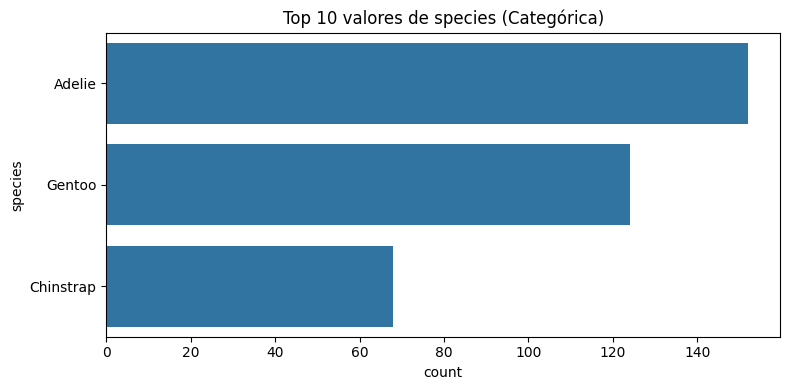

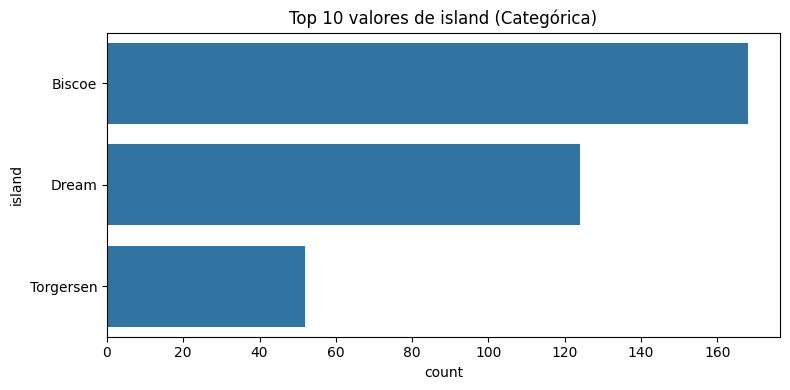

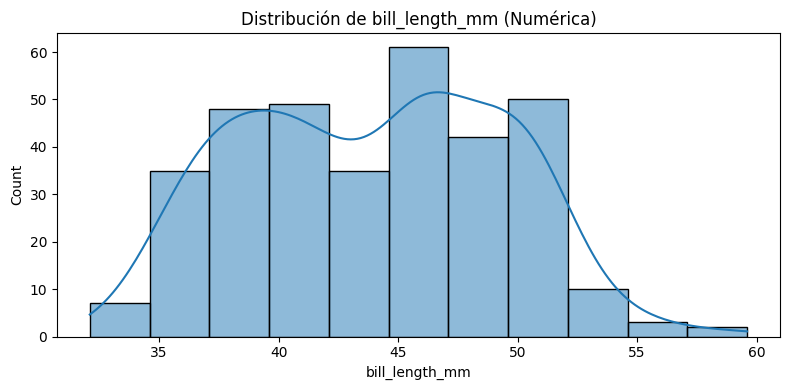

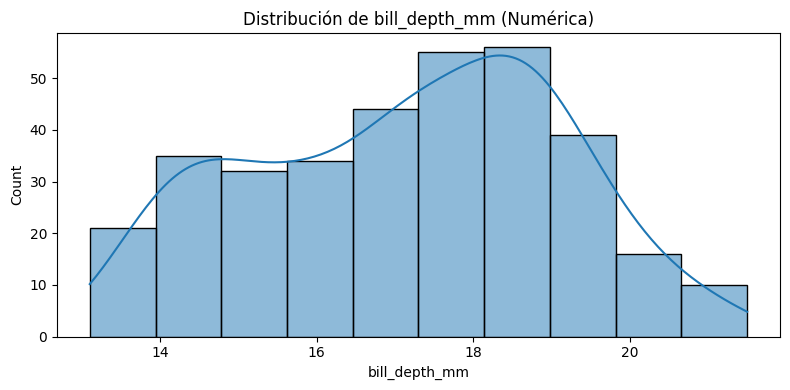

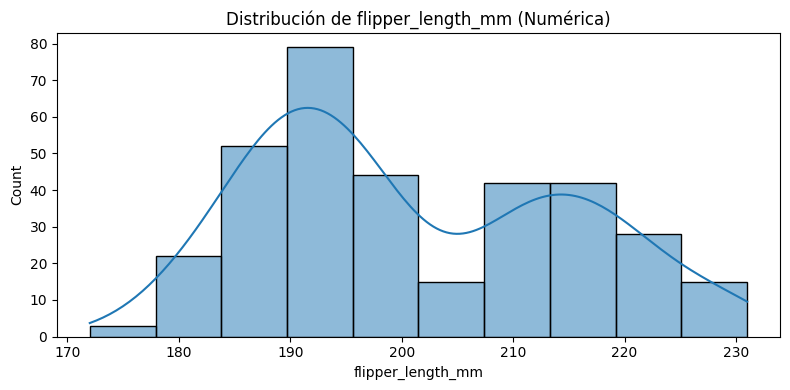

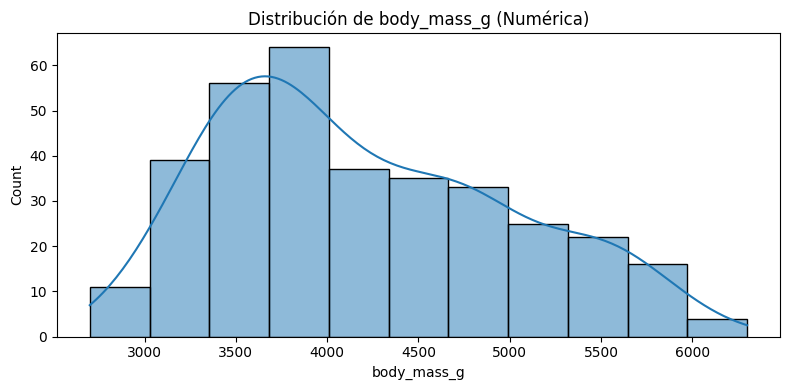

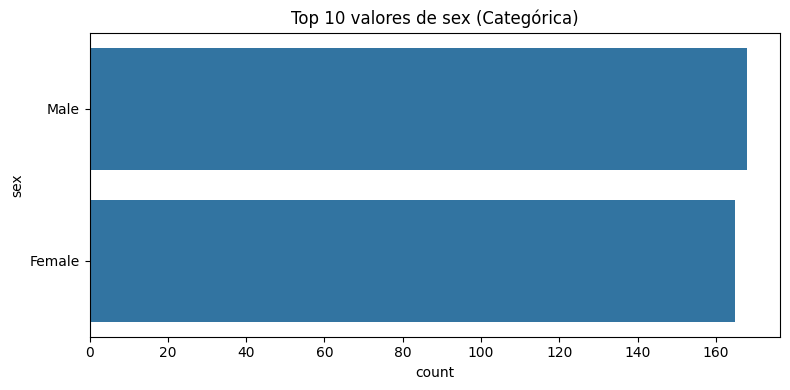

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def explorar_dataset_automatico(df):
    for col in df.columns:
        plt.figure(figsize=(8, 4))

        # Caso: Numérico (Histograma + Boxplot para ver outliers)
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna(), kde=True)
            plt.title(f'Distribución de {col} (Numérica)')

        # Caso: Categórico (Barras de frecuencia)
        else:
            # Limitamos a los 10 valores más frecuentes para no saturar el gráfico
            sns.countplot(y=df[col], order=df[col].value_counts().iloc[:10].index)
            plt.title(f'Top 10 valores de {col} (Categórica)')

        plt.tight_layout()
        plt.show()

# Ejemplo usando el dataset 'penguins' de seaborn como pide el ejercicio
df_penguins = sns.load_dataset('penguins')
explorar_dataset_automatico(df_penguins)

## Ejercicio 2: Optimización de rutas (problema aplicado)

🌍 Contexto: La empresa no dispone de un control fiable del kilometraje de los desplazamientos de sus trabajadores. Antes de implementar un sistema avanzado, se quiere realizar una prueba piloto con trabajadores ubicados en España.
Para esta prueba:

» Se trabaja con una matriz de distancias entre ciudades.

» Se quiere una solución simple, razonable y explicable.

» No se busca la ruta óptima, sino una aproximación coherente.

Carga el archivo matriu_distancies.xlsxa pandas de modo que las filas y columnas sean las ciudades y se eliminen " Las Palmas de Gran Canaria " y " Palma ".

Desarrolla una función que:

» Reciba: una ciudad de origen y una ciudad de destino.

» Regreso: el orden de las ciudades visitadas (ruta) y la distancia total recorrida.

La ruta debe construirse siguiendo una estrategia sencilla: ir siempre a la ciudad no visitada más cercana hasta llegar al destino.

In [ ]:
import pandas as pd
import numpy as np

df_dist = pd.read_excel('matriu_distancies.xlsx', index_col=0)

ciudades_a_quitar = ['Palma', 'Las Palmas de Gran Canaria']
df_dist = df_dist.drop(index=ciudades_a_quitar, columns=ciudades_a_quitar)

df_dist = df_dist.fillna(np.inf)

In [ ]:
def calcular_ruta_voraz(origen, destino, matriz):
    ruta = [origen]
    distancia_total = 0
    ciudad_actual = origen
    visitadas = {origen}

    while ciudad_actual != destino:
        distancias = matriz.loc[ciudad_actual]

        candidatas = distancias.drop(list(visitadas - {destino}))

        proxima_ciudad = candidatas.idxmin()
        distancia_paso = candidatas.min()

        ruta.append(proxima_ciudad)
        distancia_total += distancia_paso
        visitadas.add(proxima_ciudad)
        ciudad_actual = proxima_ciudad

    return ruta, distancia_total

ruta, distancia = calcular_ruta_voraz('Barcelona', 'Sevilla', df_dist)
print(f"Ruta: {' -> '.join(ruta)}")
print(f"Distancia total: {distancia} km")

Ruta: Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla
Distancia total: 1138.0 km
